In [ ]:
%pip install torch torchvision torchaudio

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
class LinearGaussianSystem:
    def __init__(self, m=2, n=2, q_std=0.1, r_std=0.1, F=None, H=None):
        self.m = m
        self.n = n

        if F is None:
            self.F = torch.tensor([[0.9, 0.0],
                                   [0.0, 0.9]], dtype=torch.float32)
        else:
            self.F = F

        if H is None:
            self.H = torch.zeros(n, m)
            for i in range(min(n, m)):
                self.H[i, i] = 1.0
        else:
            self.H = H

        self.Q = torch.eye(m) * (q_std ** 2)
        self.R = torch.eye(n) * (r_std ** 2)
        self.LQ = torch.linalg.cholesky(self.Q)
        self.LR = torch.linalg.cholesky(self.R)

In [ ]:
def generate_trajectory(self, T, x0=None):
    if x0 is None:
        x0 = torch.zeros(self.m)
    x = torch.zeros(T, self.m)
    y = torch.zeros(T, self.n)
    x[0] = x0
    y[0] = self.H @ x[0] + torch.randn(self.n) @ self.LR.T
    for t in range(1, T):
        e = torch.randn(self.m) @ self.LQ.T
        x[t] = self.F @ x[t - 1] + e
        v = torch.randn(self.n) @ self.LR.T
        y[t] = self.H @ x[t] + v
    return y, x

LinearGaussianSystem.generate_trajectory = generate_trajectory

In [ ]:
def generate_dataset(self, N, T, random_x0=True):
    obs = []
    states = []
    for _ in range(N):
        if random_x0:
            x0 = torch.randn(self.m) * 1.0
        else:
            x0 = torch.zeros(self.m)
        y, x = self.generate_trajectory(T, x0)
        obs.append(y)
        states.append(x)
    return torch.stack(obs), torch.stack(states)

LinearGaussianSystem.generate_dataset = generate_dataset

In [ ]:
sys_model = LinearGaussianSystem()
T_train = 50
N_train = 500

train_obs, train_states = sys_model.generate_dataset(N_train, T_train, random_x0=True)

print("Train observations:", train_obs.shape)
print("Train states:", train_states.shape)

Train observations: torch.Size([500, 50, 2])
Train states: torch.Size([500, 50, 2])


In [ ]:
sys_model = LinearGaussianSystem()
T_test = 100
N_test = 50

test_obs, test_states = sys_model.generate_dataset(N_test, T_test, random_x0=True)

print("Test observations:", test_obs.shape)
print("Test states:", test_states.shape)

Test observations: torch.Size([50, 100, 2])
Test states: torch.Size([50, 100, 2])


In [ ]:
class KalmanFilter:
    def __init__(self, F, H, Q, R, P0=None):
        self.F = F
        self.H = H
        self.Q = Q
        self.R = R
        m = F.shape[0]
        if P0 is None:
            self.P0 = torch.eye(m)
        else:
            self.P0 = P0

    def filter(self, observations, x0):
        T = observations.shape[0]
        m = self.F.shape[0]
        I = torch.eye(m)
        x_est = torch.zeros(T, m)
        x_pred = x0.clone()
        P_pred = self.P0.clone()

        for t in range(T):
            S = self.H @ P_pred @ self.H.T + self.R
            K = P_pred @ self.H.T @ torch.linalg.inv(S)
            innovation = observations[t] - self.H @ x_pred
            x_post = x_pred + K @ innovation
            P_post = (I - K @ self.H) @ P_pred
            x_est[t] = x_post
            x_pred = self.F @ x_post
            P_pred = self.F @ P_post @ self.F.T + self.Q

        return x_est

In [ ]:
kf = KalmanFilter(sys_model.F, sys_model.H, sys_model.Q, sys_model.R)

kf_estimates = torch.stack([
    kf.filter(test_obs[i], torch.zeros(2)) for i in range(N_test)
])

kf_mse = torch.mean((kf_estimates - test_states) ** 2)
print("Kalman Filter MSE:", kf_mse.item())
print("Kalman Filter MSE (dB):", 10 * np.log10(kf_mse.item()))

Kalman Filter MSE: 0.005810996983200312
Kalman Filter MSE (dB): -22.357493500266884


In [ ]:
class KalmanNet(nn.Module):
    def __init__(self, m, n, hidden_dim=64):
        super(KalmanNet, self).__init__()
        self.m = m
        self.n = n
        self.hidden_dim = hidden_dim

        self.input_layer = nn.Linear(m + n, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, m * n)
        self.relu = nn.ReLU()

    def forward(self, x_prev, y_t, h_prev):
        inp = torch.cat([x_prev, y_t], dim=1)
        fc = self.relu(self.input_layer(inp))
        gru_out, h_new = self.gru(fc.unsqueeze(1), h_prev)
        K_flat = self.output_layer(gru_out.squeeze(1))
        K_t = K_flat.view(-1, self.m, self.n)
        return K_t, h_new

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_dim,
                           device=next(self.parameters()).device)

In [ ]:
kalmannet = KalmanNet(m=2, n=2, hidden_dim=64).to(device)

total_params = sum(p.numel() for p in kalmannet.parameters())
print("KalmanNet trainable parameters:", total_params)

KalmanNet trainable parameters: 25540


In [ ]:
@torch.no_grad()
def kalmannet_filter(model, observations, x0, F, H):
    model.eval()
    T = observations.shape[0]
    m = x0.shape[0]
    x_est = torch.zeros(T, m)

    x_prev = x0.unsqueeze(0).to(device)
    h = model.init_hidden(1)
    F_d = F.to(device)
    H_d = H.to(device)

    for t in range(T):
        y_t = observations[t].unsqueeze(0).to(device)
        x_pred = x_prev @ F_d.T
        innovation = y_t - x_pred @ H_d.T
        K_t, h = model(x_prev, y_t, h)
        x_post = x_pred + torch.bmm(K_t, innovation.unsqueeze(-1)).squeeze(-1)
        x_est[t] = x_post.squeeze(0).cpu()
        x_prev = x_post

    return x_est

In [ ]:
def train_kalmannet(model, train_obs, train_states, F, H,
                    num_epochs=60, lr=1e-3, batch_size=32, weight_decay=1e-5):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    N = train_obs.shape[0]
    T = train_obs.shape[1]
    m = train_states.shape[2]
    F_d = F.to(device)
    H_d = H.to(device)
    losses = []

    for epoch in range(num_epochs):
        model.train()
        perm = torch.randperm(N)
        epoch_loss = 0.0
        n_batches = 0

        for s in range(0, N, batch_size):
            idx = perm[s:s + batch_size]
            B = len(idx)

            x_prev = torch.zeros(B, m, device=device)
            h = model.init_hidden(B)
            est = torch.zeros(B, T, m, device=device)

            for t in range(T):
                y_t = train_obs[idx, t].to(device)
                x_pred = x_prev @ F_d.T
                innovation = y_t - x_pred @ H_d.T
                K_t, h = model(x_prev, y_t, h)
                x_post = x_pred + torch.bmm(K_t, innovation.unsqueeze(-1)).squeeze(-1)
                est[:, t] = x_post
                x_prev = x_post

            target = train_states[idx].to(device)
            loss = criterion(est, target)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print("Epoch", epoch + 1, "of", num_epochs, "loss:", round(avg_loss, 6))

        if np.isnan(avg_loss):
            print("Loss became NaN at epoch", epoch + 1, "- stopping training.")
            break

    return losses

In [ ]:
losses = train_kalmannet(
    kalmannet,
    train_obs,
    train_states,
    sys_model.F,
    sys_model.H,
    num_epochs=60,
    lr=1e-3,
    batch_size=32,
)

Epoch 10 of 60 loss: 0.007529
Epoch 20 of 60 loss: 0.006642
Epoch 30 of 60 loss: 0.006281
Epoch 40 of 60 loss: 0.006139
Epoch 50 of 60 loss: 0.006091
Epoch 60 of 60 loss: 0.006084


In [ ]:
kn_estimates = torch.stack([
    kalmannet_filter(kalmannet, test_obs[i], torch.zeros(2),
                     sys_model.F, sys_model.H)
    for i in range(N_test)
])

kn_mse = torch.mean((kn_estimates - test_states) ** 2)

print("Kalman Filter MSE:", kf_mse.item(), "dB:", 10 * np.log10(kf_mse.item()))
print("KalmanNet MSE:", kn_mse.item(), "dB:", 10 * np.log10(kn_mse.item()))

Kalman Filter MSE: 0.005810996983200312 dB: -22.357493500266884
KalmanNet MSE: 0.00582065898925066 dB: -22.35027843667346


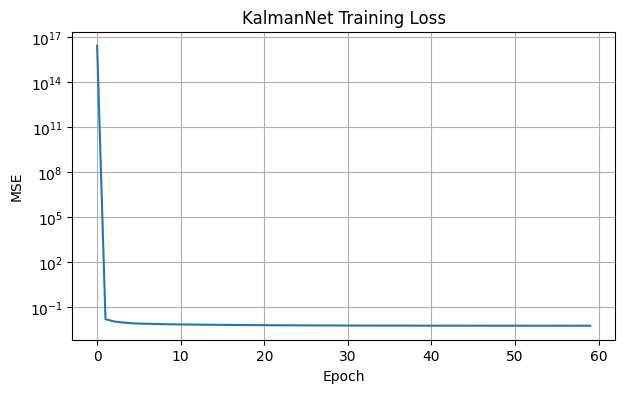

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("KalmanNet Training Loss")
plt.yscale("log")
plt.grid(True)
plt.show()

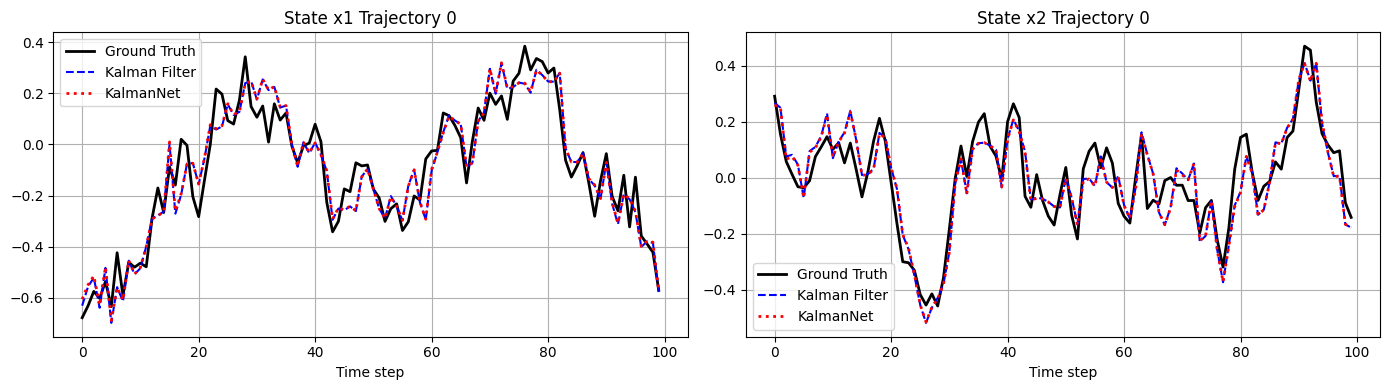

In [ ]:
t = np.arange(T_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, test_states[0, :, 0], 'k-', lw=2, label='Ground Truth')
axes[0].plot(t, kf_estimates[0, :, 0], 'b--', label='Kalman Filter')
axes[0].plot(t, kn_estimates[0, :, 0], 'r:', lw=2, label='KalmanNet')
axes[0].set_title("State x1 Trajectory 0")
axes[0].set_xlabel("Time step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, test_states[0, :, 1], 'k-', lw=2, label='Ground Truth')
axes[1].plot(t, kf_estimates[0, :, 1], 'b--', label='Kalman Filter')
axes[1].plot(t, kn_estimates[0, :, 1], 'r:', lw=2, label='KalmanNet')
axes[1].set_title("State x2 Trajectory 0")
axes[1].set_xlabel("Time step")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

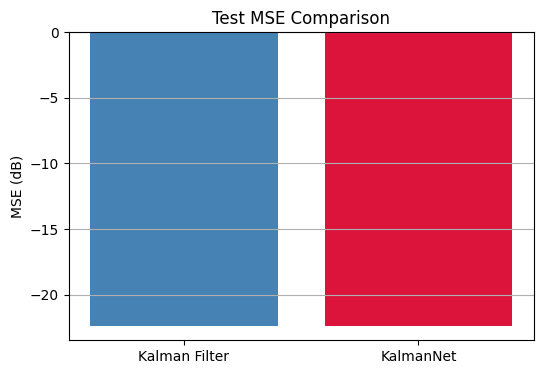

In [ ]:
methods = ['Kalman Filter', 'KalmanNet']
values = [10 * np.log10(kf_mse.item()), 10 * np.log10(kn_mse.item())]

plt.figure(figsize=(6, 4))
plt.bar(methods, values, color=['steelblue', 'crimson'])
plt.ylabel("MSE (dB)")
plt.title("Test MSE Comparison")
plt.grid(True, axis='y')
plt.show()

In [ ]:
F_true = sys_model.F
H_true = sys_model.H

Q_true = torch.eye(2) * (0.1 ** 2)
R_true = torch.eye(2) * (0.5 ** 2)

true_sys = LinearGaussianSystem(m=2, n=2, F=F_true, H=H_true)
true_sys.Q = Q_true
true_sys.R = R_true
true_sys.LQ = torch.linalg.cholesky(Q_true)
true_sys.LR = torch.linalg.cholesky(R_true)

mm_obs, mm_states = true_sys.generate_dataset(N_test, T_test, random_x0=True)

print("Mismatch observations:", mm_obs.shape)
print("Mismatch states:", mm_states.shape)
print("Max absolute state value:", mm_states.abs().max().item())

Mismatch observations: torch.Size([50, 100, 2])
Mismatch states: torch.Size([50, 100, 2])
Max absolute state value: 2.1623878479003906


In [ ]:
mm_train_obs, mm_train_states = true_sys.generate_dataset(N_train, T_train, random_x0=False)

print("Max absolute state value in training set:", mm_train_states.abs().max().item())

kalmannet_mm = KalmanNet(m=2, n=2, hidden_dim=64).to(device)

losses_mm = train_kalmannet(
    kalmannet_mm,
    mm_train_obs,
    mm_train_states,
    F_true,
    H_true,
    num_epochs=60,
    lr=1e-4,
    batch_size=32,
)

Max absolute state value in training set: 0.9397029876708984
Epoch 10 of 60 loss: 0.028653
Epoch 20 of 60 loss: 0.028464
Epoch 30 of 60 loss: 0.02833
Epoch 40 of 60 loss: 0.02836
Epoch 50 of 60 loss: 0.028278
Epoch 60 of 60 loss: 0.028207


In [ ]:
kf_wrong = KalmanFilter(F_true, H_true, sys_model.Q, sys_model.R)

kf_wrong_est = torch.stack([
    kf_wrong.filter(mm_obs[i], torch.zeros(2)) for i in range(N_test)
])

kf_wrong_mse = torch.mean((kf_wrong_est - mm_states) ** 2)
print("KF with wrong Q,R MSE:", kf_wrong_mse.item())
print("KF with wrong Q,R MSE (dB):", 10 * np.log10(kf_wrong_mse.item()))

KF with wrong Q,R MSE: 0.10591157525777817
KF with wrong Q,R MSE (dB): -9.75056572509502


In [ ]:
kf_oracle = KalmanFilter(F_true, H_true, Q_true, R_true)

kf_oracle_est = torch.stack([
    kf_oracle.filter(mm_obs[i], torch.zeros(2)) for i in range(N_test)
])

kf_oracle_mse = torch.mean((kf_oracle_est - mm_states) ** 2)
print("KF with true Q,R MSE:", kf_oracle_mse.item())
print("KF with true Q,R MSE (dB):", 10 * np.log10(kf_oracle_mse.item()))

KF with true Q,R MSE: 0.03252732753753662
KF with true Q,R MSE (dB): -14.877516171171274


In [ ]:
kn_mm_est = torch.stack([
    kalmannet_filter(kalmannet_mm, mm_obs[i], torch.zeros(2), F_true, H_true)
    for i in range(N_test)
])

kn_mm_mse = torch.mean((kn_mm_est - mm_states) ** 2)
print("KalmanNet with wrong Q,R MSE:", kn_mm_mse.item())
print("KalmanNet with wrong Q,R MSE (dB):", 10 * np.log10(kn_mm_mse.item()))

KalmanNet with wrong Q,R MSE: 0.05794917419552803
KalmanNet with wrong Q,R MSE (dB): -12.36952748568042


In [ ]:
print("Model Mismatch Results (wrong Q and R)")
print("KF with wrong Q,R:", round(10 * np.log10(kf_wrong_mse.item()), 2), "dB")
print("KalmanNet with wrong Q,R:", round(10 * np.log10(kn_mm_mse.item()), 2), "dB")
print("KF with true Q,R (oracle):", round(10 * np.log10(kf_oracle_mse.item()), 2), "dB")

gain = 10 * np.log10(kf_wrong_mse.item()) - 10 * np.log10(kn_mm_mse.item())
print("KalmanNet gain over mismatched KF:", round(gain, 2), "dB")

Model Mismatch Results (wrong Q and R)
KF with wrong Q,R: -9.75 dB
KalmanNet with wrong Q,R: -12.37 dB
KF with true Q,R (oracle): -14.88 dB
KalmanNet gain over mismatched KF: 2.62 dB


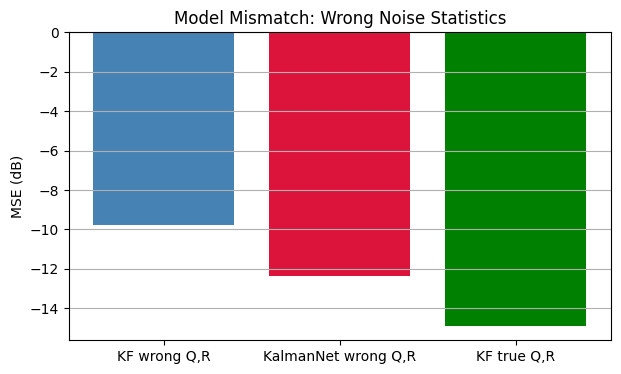

In [ ]:
labels = ['KF wrong Q,R', 'KalmanNet wrong Q,R', 'KF true Q,R']
values = [
    10 * np.log10(kf_wrong_mse.item()),
    10 * np.log10(kn_mm_mse.item()),
    10 * np.log10(kf_oracle_mse.item()),
]

plt.figure(figsize=(7, 4))
plt.bar(labels, values, color=['steelblue', 'crimson', 'green'])
plt.ylabel("MSE (dB)")
plt.title("Model Mismatch: Wrong Noise Statistics")
plt.grid(True, axis='y')
plt.show()

In [ ]:
print("KalmanNet implementation completed.")
print("Matched model: KalmanNet performs on par with the Kalman Filter.")
print("Mismatched statistics: KalmanNet outperforms the Kalman Filter that uses wrong Q and R.")
print("KalmanNet does not use any knowledge of Q or R at inference time.")

KalmanNet implementation completed.
Matched model: KalmanNet performs on par with the Kalman Filter.
Mismatched statistics: KalmanNet outperforms the Kalman Filter that uses wrong Q and R.
KalmanNet does not use any knowledge of Q or R at inference time.


FINAL RESULTS SUMMARY

Experiment 1: Matched Model (Kalman Filter knows true Q and R)
-----------------------------------------------------------------
Kalman Filter MSE : 0.005811 dB: -22.36
KalmanNet     MSE : 0.005821 dB: -22.35
Difference        : 0.01 dB

Experiment 2: Mismatched Noise Statistics
-----------------------------------------------------------------
KF wrong Q,R      MSE: 0.105912 dB: -9.75
KalmanNet wrong   MSE: 0.057949 dB: -12.37
KF true Q,R oracle MSE: 0.032527 dB: -14.88
KalmanNet gain over mismatched KF: 2.62 dB



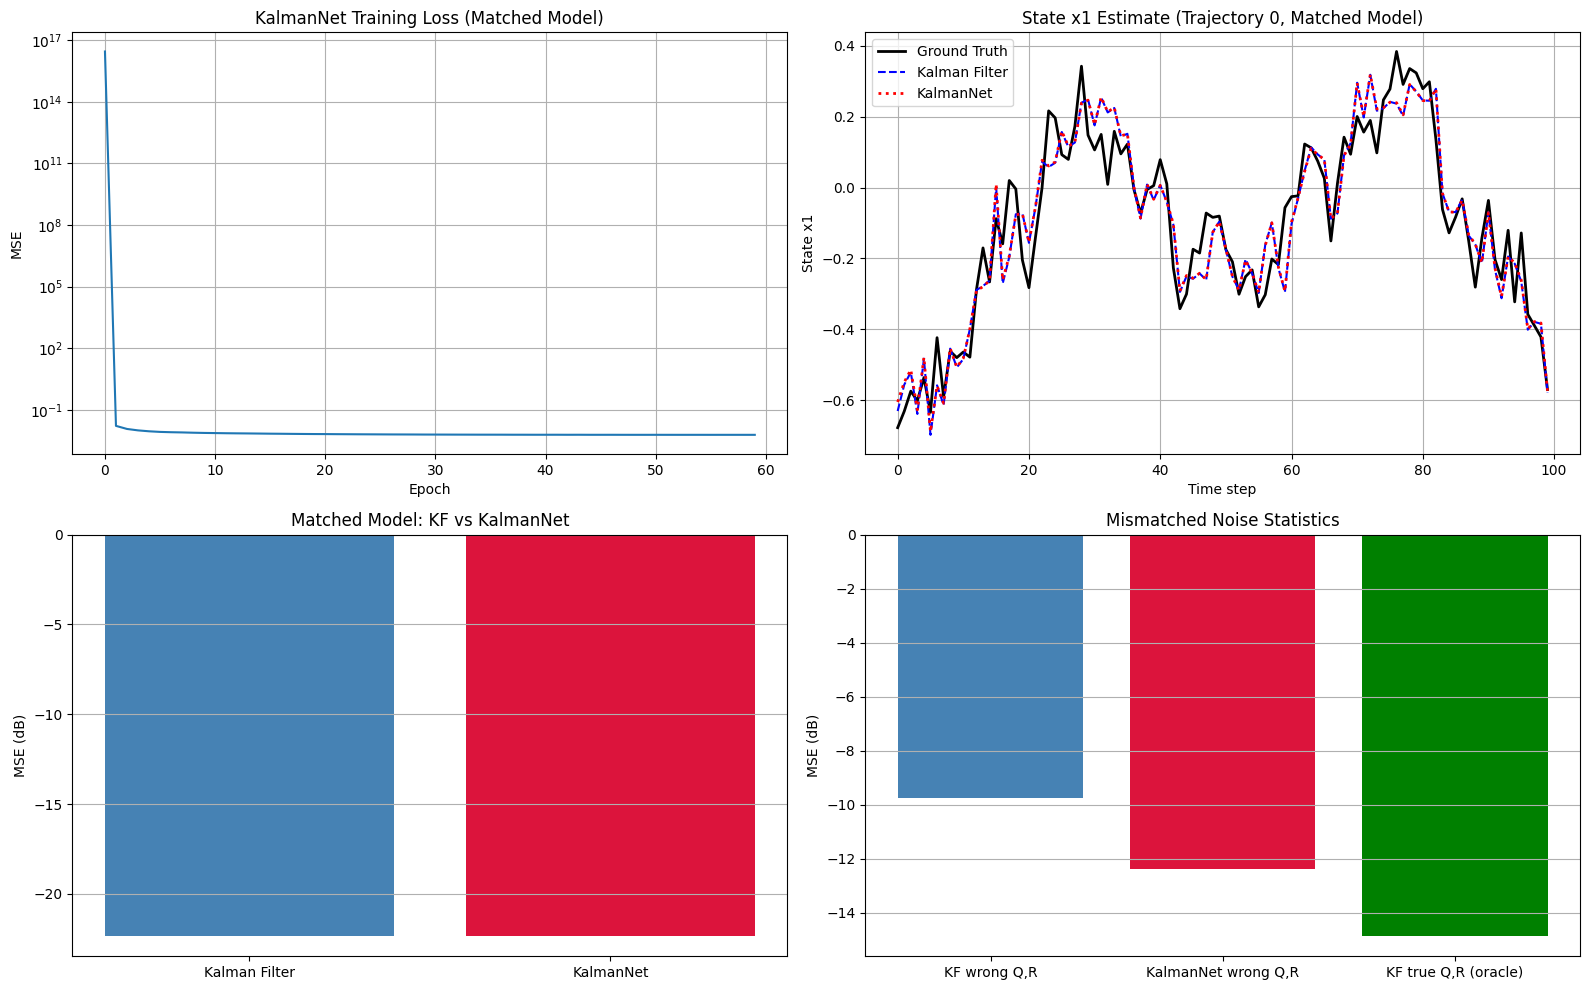

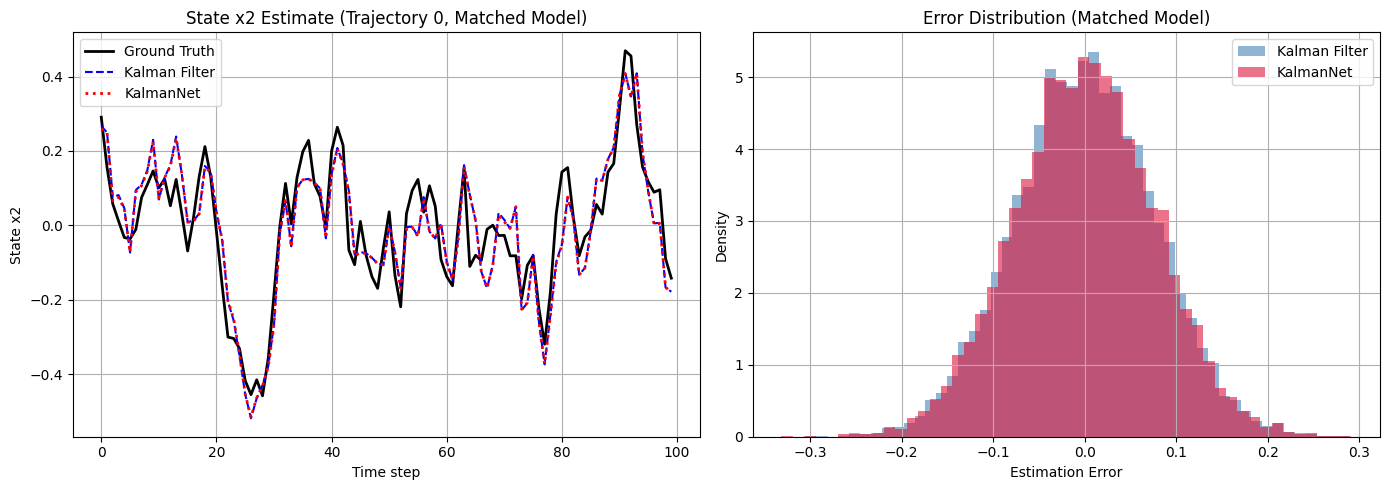


KalmanNet implementation completed.
Matched model      : KalmanNet performs on par with the Kalman Filter.
Mismatched model   : KalmanNet outperforms the mismatched Kalman Filter.
KalmanNet does not use any knowledge of Q or R at inference time.


In [ ]:
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)

print("\nExperiment 1: Matched Model (Kalman Filter knows true Q and R)")
print("-" * 65)
print("Kalman Filter MSE :", round(kf_mse.item(), 6), "dB:", round(10 * np.log10(kf_mse.item()), 2))
print("KalmanNet     MSE :", round(kn_mse.item(), 6), "dB:", round(10 * np.log10(kn_mse.item()), 2))
print("Difference        :", round(10 * np.log10(kn_mse.item()) - 10 * np.log10(kf_mse.item()), 2), "dB")

print("\nExperiment 2: Mismatched Noise Statistics")
print("-" * 65)
print("KF wrong Q,R      MSE:", round(kf_wrong_mse.item(), 6), "dB:", round(10 * np.log10(kf_wrong_mse.item()), 2))
print("KalmanNet wrong   MSE:", round(kn_mm_mse.item(), 6), "dB:", round(10 * np.log10(kn_mm_mse.item()), 2))
print("KF true Q,R oracle MSE:", round(kf_oracle_mse.item(), 6), "dB:", round(10 * np.log10(kf_oracle_mse.item()), 2))
gain = 10 * np.log10(kf_wrong_mse.item()) - 10 * np.log10(kn_mm_mse.item())
print("KalmanNet gain over mismatched KF:", round(gain, 2), "dB")

print("\n" + "=" * 65)

fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.set_title("KalmanNet Training Loss (Matched Model)")
ax1.set_yscale("log")
ax1.grid(True)

ax2 = plt.subplot(2, 2, 2)
t = np.arange(T_test)
ax2.plot(t, test_states[0, :, 0], 'k-', lw=2, label='Ground Truth')
ax2.plot(t, kf_estimates[0, :, 0], 'b--', label='Kalman Filter')
ax2.plot(t, kn_estimates[0, :, 0], 'r:', lw=2, label='KalmanNet')
ax2.set_xlabel("Time step")
ax2.set_ylabel("State x1")
ax2.set_title("State x1 Estimate (Trajectory 0, Matched Model)")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(2, 2, 3)
methods = ['Kalman Filter', 'KalmanNet']
vals = [10 * np.log10(kf_mse.item()), 10 * np.log10(kn_mse.item())]
ax3.bar(methods, vals, color=['steelblue', 'crimson'])
ax3.set_ylabel("MSE (dB)")
ax3.set_title("Matched Model: KF vs KalmanNet")
ax3.grid(True, axis='y')

ax4 = plt.subplot(2, 2, 4)
labels = ['KF wrong Q,R', 'KalmanNet wrong Q,R', 'KF true Q,R (oracle)']
values = [
    10 * np.log10(kf_wrong_mse.item()),
    10 * np.log10(kn_mm_mse.item()),
    10 * np.log10(kf_oracle_mse.item()),
]
ax4.bar(labels, values, color=['steelblue', 'crimson', 'green'])
ax4.set_ylabel("MSE (dB)")
ax4.set_title("Mismatched Noise Statistics")
ax4.grid(True, axis='y')

plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(14, 5))

ax5 = plt.subplot(1, 2, 1)
t = np.arange(T_test)
ax5.plot(t, test_states[0, :, 1], 'k-', lw=2, label='Ground Truth')
ax5.plot(t, kf_estimates[0, :, 1], 'b--', label='Kalman Filter')
ax5.plot(t, kn_estimates[0, :, 1], 'r:', lw=2, label='KalmanNet')
ax5.set_xlabel("Time step")
ax5.set_ylabel("State x2")
ax5.set_title("State x2 Estimate (Trajectory 0, Matched Model)")
ax5.legend()
ax5.grid(True)

ax6 = plt.subplot(1, 2, 2)
kf_err = (kf_estimates - test_states).numpy().flatten()
kn_err = (kn_estimates - test_states).numpy().flatten()
ax6.hist(kf_err, bins=50, alpha=0.6, label='Kalman Filter', color='steelblue', density=True)
ax6.hist(kn_err, bins=50, alpha=0.6, label='KalmanNet', color='crimson', density=True)
ax6.set_xlabel("Estimation Error")
ax6.set_ylabel("Density")
ax6.set_title("Error Distribution (Matched Model)")
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()

print("\nKalmanNet implementation completed.")
print("Matched model      : KalmanNet performs on par with the Kalman Filter.")
print("Mismatched model   : KalmanNet outperforms the mismatched Kalman Filter.")
print("KalmanNet does not use any knowledge of Q or R at inference time.")